In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
#loading data
df =  pd.read_csv('train_premium.csv')

In [8]:
df = df.drop(columns=['Policy Start Date']) 

In [9]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,Poor,Yes,Weekly,House,2022.0


In [10]:
# drop id
df = df.drop(columns=["id"])


Text(0.5, 1.0, 'Premium Distribution for Mixed Insurance')

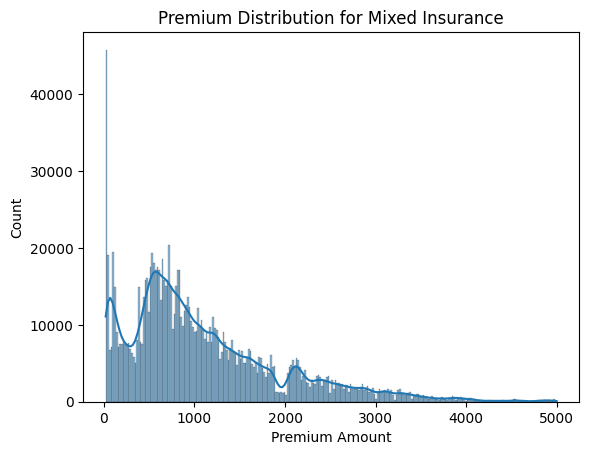

In [11]:
sns.histplot(df['Premium Amount'], kde=True)
plt.title('Premium Distribution for Mixed Insurance')

<Axes: xlabel='Annual Income', ylabel='Count'>

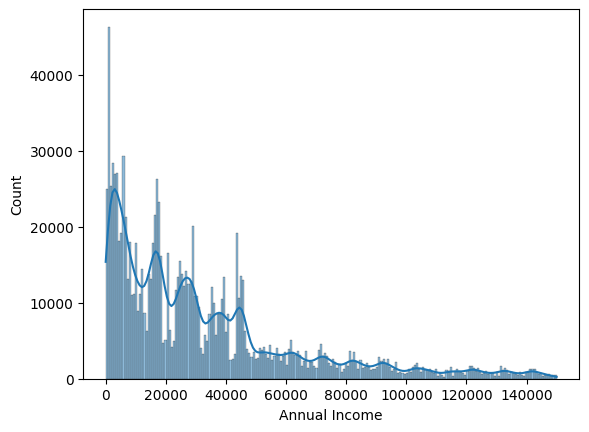

In [12]:
sns.histplot(df['Annual Income'], kde=True)

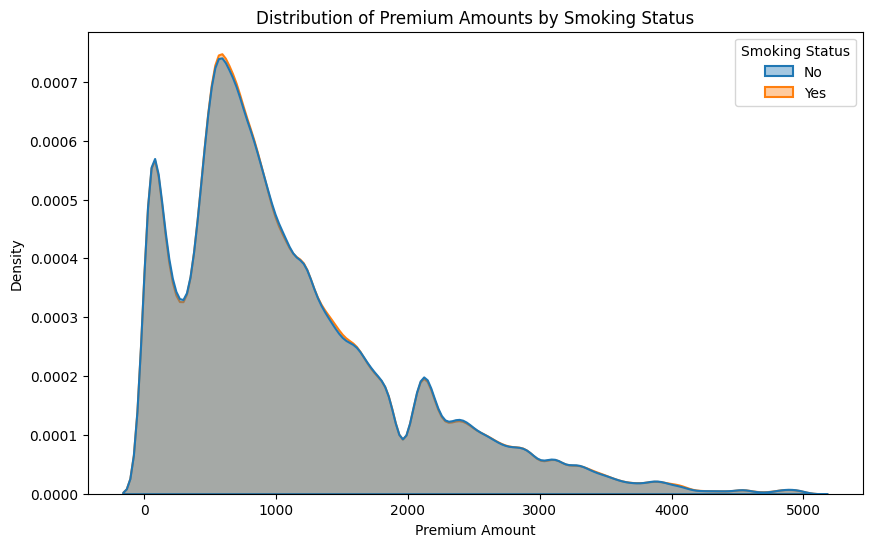

In [13]:
df_sample = df.sample(n=20000, random_state=42)

# 2. Setup the Plot
# We use 'kdeplot' with multiple levels to create the "Ridge" effect
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, 
    x='Premium Amount', 
    hue='Smoking Status', 
    fill=True, 
    common_norm=False, 
    alpha=0.4, 
    linewidth=1.5
)

plt.title('Distribution of Premium Amounts by Smoking Status')
plt.xlabel('Premium Amount')
plt.ylabel('Density')
plt.show()

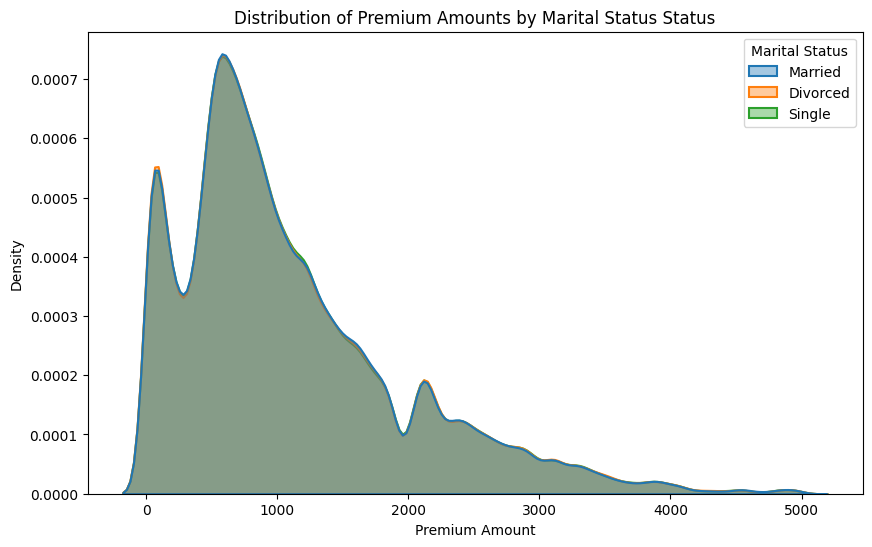

In [14]:
df_sample = df.sample(n=20000, random_state=42)

# 2. Setup the Plot
# We use 'kdeplot' with multiple levels to create the "Ridge" effect
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, 
    x='Premium Amount', 
    hue='Marital Status', 
    fill=True, 
    common_norm=False, 
    alpha=0.4, 
    linewidth=1.5
)

plt.title('Distribution of Premium Amounts by Marital Status Status')
plt.xlabel('Premium Amount')
plt.ylabel('Density')
plt.show()

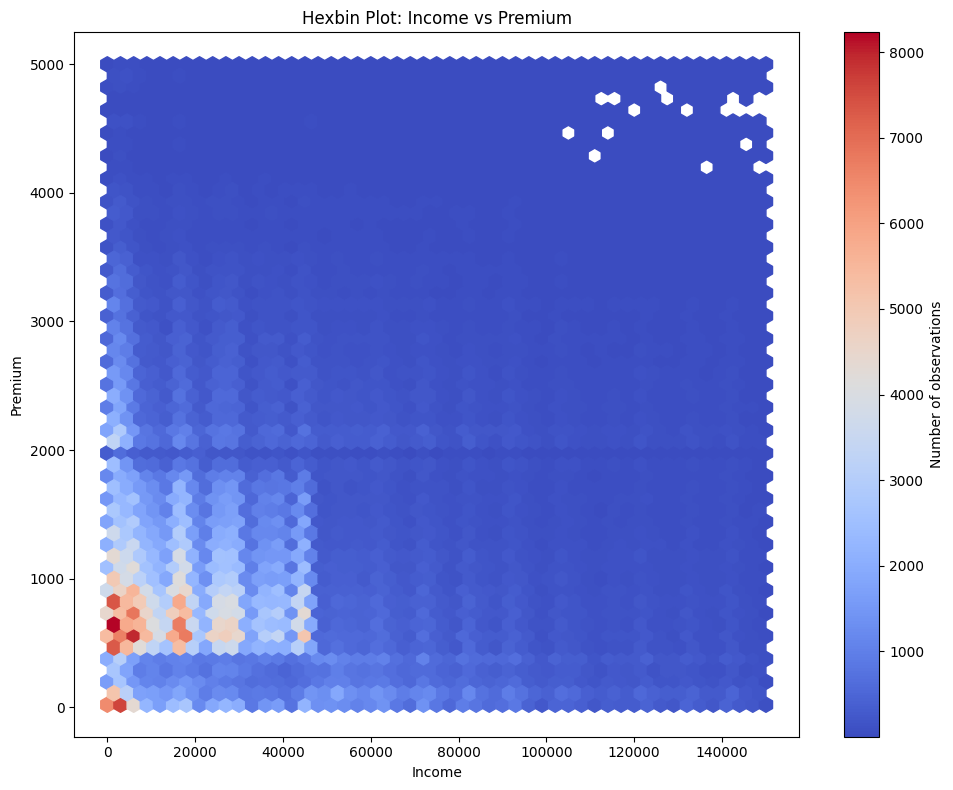

In [15]:
# Create the Hexbin plot
plt.figure(figsize=(10, 8))

# gridsize controls how many hexagons you want (adjust based on your preference)
# mincnt=1 ensures we don't plot bins with zero points (making it cleaner)
hb = plt.hexbin(df['Annual Income'], df['Premium Amount'], gridsize=50, cmap='coolwarm', mincnt=1)

# Add a colorbar to show the density scale
cb = plt.colorbar(hb, label='Number of observations')

plt.title('Hexbin Plot: Income vs Premium')
plt.xlabel('Income')
plt.ylabel('Premium')

# Ensure layout is clean
plt.tight_layout()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1181295 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1155051 non-null  float64
 3   Marital Status        1181471 non-null  object 
 4   Number of Dependents  1090328 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Occupation            841925 non-null   object 
 7   Health Score          1125924 non-null  float64
 8   Location              1200000 non-null  object 
 9   Policy Type           1200000 non-null  object 
 10  Previous Claims       835971 non-null   float64
 11  Vehicle Age           1199994 non-null  float64
 12  Credit Score          1062118 non-null  float64
 13  Insurance Duration    1199999 non-null  float64
 14  Customer Feedback     1122176 non-

In [17]:
df.isnull().sum()

Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [18]:
#To check whether annual incomes are missing at random
df1 = df.copy()

df1['Income_Missing'] = df1['Annual Income'].isna().astype(int)

# Check if the average Premium differs significantly when income is missing
print(df1.groupby('Income_Missing')['Premium Amount'].mean())

Income_Missing
0    1109.251625
1     930.200605
Name: Premium Amount, dtype: float64


In [19]:
df['Income_Missing'] = df['Annual Income'].isna().astype(int)

In [20]:
df['Premium Amount'].describe()

count    1.200000e+06
mean     1.102545e+03
std      8.649989e+02
min      2.000000e+01
25%      5.140000e+02
50%      8.720000e+02
75%      1.509000e+03
max      4.999000e+03
Name: Premium Amount, dtype: float64

In [21]:
df['Annual Income'] = np.log1p(df['Annual Income'])


In [22]:
df['Annual Income']=df['Annual Income'].fillna(df['Annual Income'].median())

In [23]:
df['Premium Amount'] = np.log1p(df['Premium Amount'])

In [24]:
df['Customer Feedback'].unique()

array(['Poor', 'Average', 'Good', nan], dtype=object)

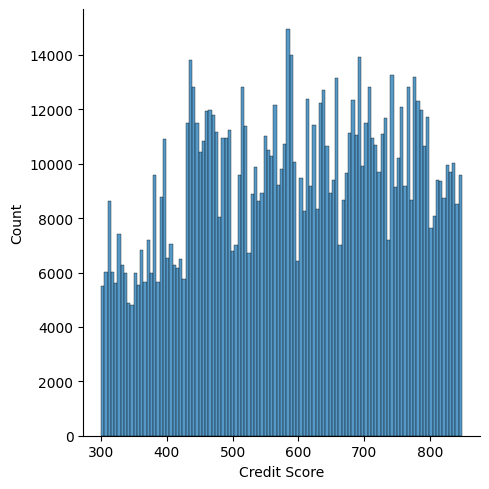

In [25]:
sns.displot(df['Credit Score'])

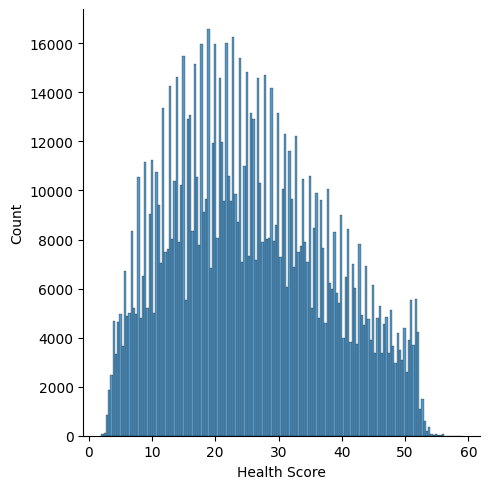

In [26]:
sns.displot(df['Health Score'])

In [27]:
df['Occupation'] = df['Occupation'].fillna('Unknown', inplace=True)

/var/folders/tx/1dyqxkm52yd54jrcwkb48jtc0000gp/T/ipykernel_29874/3940566394.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Occupation'] = df['Occupation'].fillna('Unknown', inplace=True)


In [28]:
X = df.drop(columns=["Premium Amount"])
y = df["Premium Amount"]

In [29]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1181295 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1200000 non-null  float64
 3   Marital Status        1181471 non-null  object 
 4   Number of Dependents  1090328 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Occupation            0 non-null        object 
 7   Health Score          1125924 non-null  float64
 8   Location              1200000 non-null  object 
 9   Policy Type           1200000 non-null  object 
 10  Previous Claims       835971 non-null   float64
 11  Vehicle Age           1199994 non-null  float64
 12  Credit Score          1062118 non-null  float64
 13  Insurance Duration    1199999 non-null  float64
 14  Customer Feedback     1122176 non-

# Preprocessing
Based on description of dataset, we know categorical coolumns and their unique values. These coulumns are encoded using mix of Ordinal and OneHotEncoder. For column occupation and Customer feedback, missing values are assigned -1. 

In [30]:
from sklearn.model_selection import train_test_split as holdout
X_train, X_test, y_train, y_test = holdout(X, y, test_size=0.2, random_state=0)

In [31]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# 1. Identify column groups
float_cols = X.select_dtypes(include=['float64']).columns.tolist()
ord_cols = ['Education Level', 'Occupation', 'Location', 'Customer Feedback', 
                'Policy Type', 'Smoking Status', 'Exercise Frequency']
# 2. Define Ordinal Mappings
ord_map = {
    'Education Level': ['High School', "Bachelor's", "Master's", 'PhD'],
    'Occupation': ['Unemployed', 'Employed', 'Self-Employed', 'Unknown'],
    'Location': ['Rural', 'Suburban', 'Urban'],
    'Customer Feedback': ['Poor', 'Average', 'Good'],
    'Policy Type': ['Basic', 'Comprehensive', 'Premium'],
    'Smoking Status': ['No', 'Yes'],
    'Exercise Frequency': ['Rarely', 'Monthly', 'Weekly', 'Daily']
}

# 3. Setup Pipelines
# Numeric: Median Impute -> Scale
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ordinal: Impute with 'missing' with -1 -> Encode
ord_pipe = Pipeline([
    ('encoder', OrdinalEncoder(
        categories=[ord_map[col] for col in ord_cols], 
        handle_unknown='use_encoded_value', # Allows the encoder to handle new/missing data
        unknown_value=-1,                   # Maps unknown/missing values to -1
        encoded_missing_value=-1            # Explicitly maps NaNs to -1
    )), ('scaler', StandardScaler()) 
])



# One-Hot: Impute -> OneHot
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# 4. Final Transformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, float_cols),
    ('ord', ord_pipe, ord_cols),
    ('ohe', ohe_pipe, ['Gender', 'Marital Status', 'Property Type'])
])

# Fit and transform
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [32]:
X_train_scaled.shape

(960000, 21)

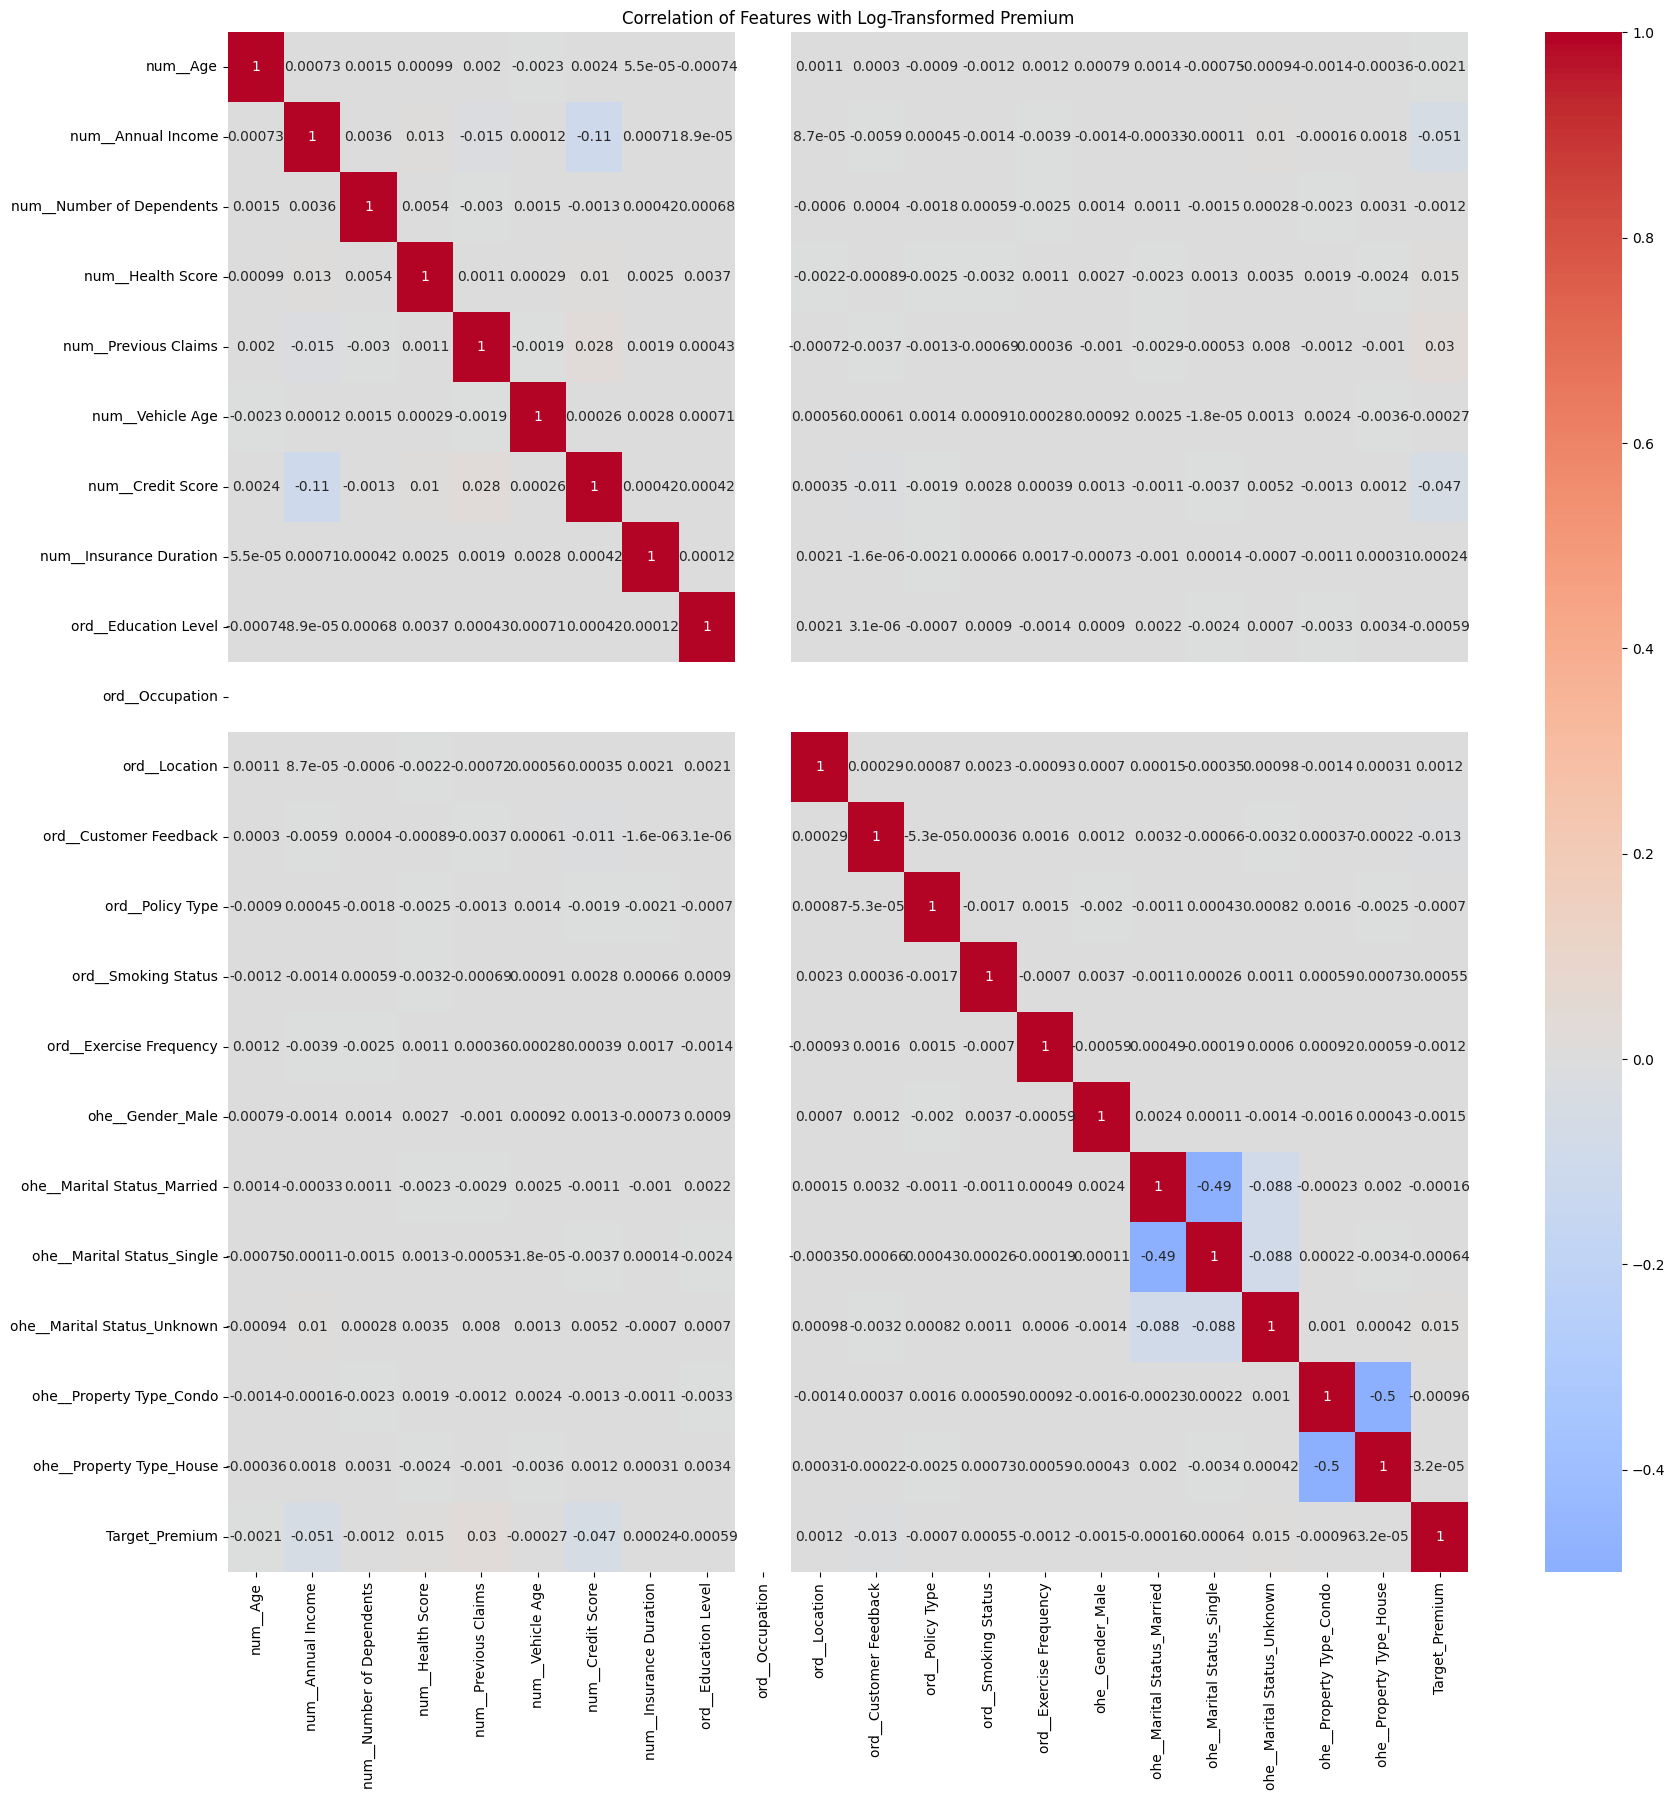

In [33]:
# 1. Get processed training data as a DataFrame
feature_names = preprocessor.get_feature_names_out()
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)

# 2. Add y_train back to this DataFrame
# Reset indices is important to ensure they align correctly
X_train_scaled = X_train_scaled.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

df_analysis = pd.concat([X_train_scaled, y_train_reset], axis=1)

# 3. Rename target for clarity in the heatmap
df_analysis.rename(columns={'Premium Amount': 'Target_Premium'}, inplace=True)

# 4. Compute and plot correlation
plt.figure(figsize=(20, 20))
corr_matrix = df_analysis.corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0
)
plt.title('Correlation of Features with Log-Transformed Premium')
plt.show()

## NOW MAKING AND APPLYING MODELS

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [35]:
df_scores = pd.DataFrame(columns=['Model', 'Evaluation_Type', 'RMSE', 'MAE', 'R2'])
print("df_scores DataFrame initialized with specified columns.")

df_scores DataFrame initialized with specified columns.


In [36]:
# Initialize a fresh df_scores with both versions
df_scores = pd.DataFrame(columns=['Model', 'Evaluation_Type', 'RMSE', 'MAE', 'R2',
                                   'RMSE_original', 'MAE_original', 'R2_original'])

def evaluate_model(model, X_test, y_test_log):
    global df_scores
    
    # --- Log scale (what model was trained on) ---
    predictions_log = model.predict(X_test)
    mse  = mean_squared_error(y_test_log, predictions_log)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_log, predictions_log)
    r2   = r2_score(y_test_log, predictions_log)

    # --- Original scale (reverse log1p transformation) ---
    predictions_orig = np.expm1(predictions_log)
    y_test_orig      = np.expm1(y_test_log)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, predictions_orig))
    mae_orig  = mean_absolute_error(y_test_orig, predictions_orig)
    r2_orig   = r2_score(y_test_orig, predictions_orig)

    new_row = pd.DataFrame([{
        'Model':           model.__class__.__name__,
        'Evaluation_Type': 'Test Set',
        'RMSE':            rmse,
        'MAE':             mae,
        'R2':              r2,
        'RMSE_original':   rmse_orig,
        'MAE_original':    mae_orig,
        'R2_original':     r2_orig
    }])
    df_scores = pd.concat([df_scores, new_row], ignore_index=True)

    print(f"[{model.__class__.__name__}]")
    print(f"  Log scale  — RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    print(f"  Orig scale — RMSE: {rmse_orig:.2f} | MAE: {mae_orig:.2f} | R2: {r2_orig:.4f}")
    
    return rmse, mae, r2, rmse_orig, mae_orig, r2_orig

In [37]:
from sklearn.linear_model import LinearRegression

Lin_reg = LinearRegression()
model_lr = Lin_reg.fit(X_train_scaled, y_train)
evaluate_model(model_lr, X_test_scaled, y_test)

[LinearRegression]
  Log scale  — RMSE: 1.0934 | MAE: 0.7967 | R2: 0.0077
  Orig scale — RMSE: 939.09 | MAE: 650.22 | R2: -0.1780


/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/var/folders/tx/1dyqxkm52yd54jrcwkb48jtc0000gp/T/ipykernel_29874/1896597272.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_scores = pd.concat([df_scores, new_row], ignore_index=True)


(np.float64(1.0934463603795679),
 0.7966573518625919,
 0.0076815183599098225,
 np.float64(939.0935068776133),
 650.2189842130642,
 -0.17797305433044208)

Now apply random forest regressor and other models

# To find parameters for RandomForest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

Define your parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2'] 
}

Initialize the model
rf = RandomForestRegressor(random_state=42, n_jobs=-1) # n_jobs=-1 uses all CPU cores

'cv=3' is safer for 1.2M rows to keep runtime manageable
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    verbose=2, 
    scoring='neg_mean_squared_error',
    random_state=42
)

Fit on processed training data
random_search.fit(X_train_processed, y_train)

 View the results
print(f"Best parameters: {random_search.best_params_}")
output: 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 300

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    max_depth=20, 
    max_features='log2', 
    min_samples_leaf=4, 
    min_samples_split=5, 
    n_estimators=300,
    random_state=42, # Always good practice for research reproducibility
    n_jobs=-1        # Uses all CPU cores to speed up training
)

model_rf = rf_reg.fit(X_train_scaled, y_train)
evaluate_model(model_rf, X_test_scaled, y_test)

/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


[RandomForestRegressor]
  Log scale  — RMSE: 1.0565 | MAE: 0.7526 | R2: 0.0735
  Orig scale — RMSE: 928.81 | MAE: 625.69 | R2: -0.1523


(np.float64(1.0565491863808474),
 0.7525567629621105,
 0.0735210568536584,
 np.float64(928.8105927926595),
 625.6943071038079,
 -0.15231708290050738)

In [39]:
feature_importances_rf = model_rf.feature_importances_
feature_names_rf = preprocessor.get_feature_names_out()
# Verify lengths match before building DataFrame
print(f"Feature names length : {len(feature_names_rf)}")
print(f"Importances length   : {len(feature_importances_rf)}")

importance_df_rf = pd.DataFrame({
    'Feature':    feature_names_rf,
    'Importance': feature_importances_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Features from Tuned RandomForestRegressor Model:")
display(importance_df_rf.head(5))

Feature names length : 21
Importances length   : 21
Top 5 Most Important Features from Tuned RandomForestRegressor Model:


,Feature,Importance
1,num__Annual Income,0.235464
6,num__Credit Score,0.166479
3,num__Health Score,0.135135
0,num__Age,0.077400
5,num__Vehicle Age,0.062922


In [40]:
# we see that the model isn't considering our categorical variables.

In [41]:
#Findings so far: linear regression is a baseline model but in this dataset where there isn't strong correlation, it ddoesn't perform well. 


In [42]:
from xgboost import XGBRegressor


from sklearn.model_selection import RandomizedSearchCV


# Parameter grid to search
param_dist = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':        [0, 0.1, 0.5],    # L1
    'reg_lambda':       [1, 1.5, 2.0],    # L2
}

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'   # Fast for large datasets like yours (1.2M rows)
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,            # More iterations than RF since XGB is faster to train
    cv=3,
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train_scaled, y_train)

print(f"Best parameters: {random_search_xgb.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-random_search_xgb.best_score_):.4f}")
output: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

In [43]:
xgb_reg = XGBRegressor(subsample=0.6, 
                       reg_lambda=2.0, 
                       reg_alpha=0,
                       n_estimators=700,
                       min_child_weight=1, 
                       max_depth=7, 
                       learning_rate=0.01, 
                       colsample_bytree=1.0)
model_xgb = xgb_reg.fit(X_train_scaled, y_train)
evaluate_model(model_xgb, X_test_scaled, y_test)

[XGBRegressor]
  Log scale  — RMSE: 1.0523 | MAE: 0.7470 | R2: 0.0810
  Orig scale — RMSE: 925.75 | MAE: 622.25 | R2: -0.1447


(np.float64(1.0522688583252993),
 0.7470300191448352,
 0.08101261713091001,
 np.float64(925.7499166511969),
 622.253351047643,
 -0.14473521756131702)

In [44]:
from sklearn.neural_network import MLPRegressor



 Subsample — 50k rows is plenty to find good hyperparameters
from sklearn.utils import resample
X_sample, y_sample = resample(X_train_scaled, y_train, 
                               n_samples=50000, 
                               random_state=42)


param_dist = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],  # removed large architectures
    'activation':         ['relu'],                               # relu almost always wins
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.0001],
    'batch_size':         [128, 256]                              # larger batch = faster
}

mlp = MLPRegressor(
    solver='adam',          # fixed — best for large data
    early_stopping=True,    # fixed — stops wasted iterations
    max_iter=200,           # fixed — early stopping handles the rest
    random_state=42
)

random_search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=10,              # reduced from 20
    cv=3,
    verbose=2,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search_mlp.fit(X_sample, y_sample)

print(f"Best parameters: {random_search_mlp.best_params_}")
print(f"Best CV RMSE:     {-random_search_mlp.best_score_:.4f}")
output = {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'batch_size': 256, 'alpha': 0.0001, 'activation': 'relu'}


In [45]:
# Refit with best parameters
best_mlp = MLPRegressor(
    learning_rate_init = 0.001, 
    hidden_layer_sizes = (128, 64), 
    batch_size = 256, 
    alpha = 0.0001, 
    activation= 'relu',
    random_state=42
)

model_mlp = best_mlp.fit(X_train_scaled, y_train)
evaluate_model(model_mlp, X_test_scaled, y_test)

/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


[MLPRegressor]
  Log scale  — RMSE: 1.0675 | MAE: 0.7591 | R2: 0.0542
  Orig scale — RMSE: 922.47 | MAE: 628.48 | R2: -0.1366


(np.float64(1.0674883008708742),
 0.7590530147646402,
 0.05423690874022402,
 np.float64(922.4656140434204),
 628.4787607900389,
 -0.13662722276581718)

#Alternate ANN model
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import KFold
import numpy as np

def build_model(hidden_units, activation, learning_rate, alpha):
    model = keras.Sequential([
        keras.layers.Dense(hidden_units[0], activation=activation, 
                          kernel_regularizer=keras.regularizers.l2(alpha),
                          input_shape=(X_train_scaled.shape[1],))
    ])
    for units in hidden_units[1:]:
        model.add(keras.layers.Dense(units, activation=activation,
                                    kernel_regularizer=keras.regularizers.l2(alpha)))
    model.add(keras.layers.Dense(1))  # output layer
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

param_grid = [
    {'hidden_units': [64, 32],      'activation': 'relu', 'lr': 0.001,  'alpha': 0.0001},
    {'hidden_units': [128, 64],     'activation': 'relu', 'lr': 0.001,  'alpha': 0.001},
    {'hidden_units': [128, 64, 32], 'activation': 'relu', 'lr': 0.0001, 'alpha': 0.0001},
]

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

best_rmse   = np.inf
best_params = None

for params in param_grid:
    model = build_model(params['hidden_units'], params['activation'],
                        params['lr'], params['alpha'])
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.1,       # 10% of training data for validation
        epochs=50,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )
    
    val_rmse = np.sqrt(min(history.history['val_loss']))
    print(f"Params: {params} → Val RMSE: {val_rmse:.4f}")
    
    if val_rmse < best_rmse:
        best_rmse   = val_rmse
        best_params = params
        best_model  = model                 

print(f"\nBest params: {best_params}")
print(f"Best Val RMSE: {best_rmse:.4f}")

Output: Best params: {'hidden_units': [64, 32], 'activation': 'relu', 'lr': 0.001, 'alpha': 0.0001}
Best Val RMSE: 1.0643

/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 2s 412us/step - loss: 3.2327 - mae: 1.2144 - val_loss: 1.1882 - val_mae: 0.7975 - learning_rate: 0.0010
Epoch 2/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 2s 465us/step - loss: 1.1935 - mae: 0.7927 - val_loss: 1.1788 - val_mae: 0.7762 - learning_rate: 0.0010
Epoch 3/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 1s 402us/step - loss: 1.1876 - mae: 0.7891 - val_loss: 1.1755 - val_mae: 0.7868 - learning_rate: 0.0010
Epoch 4/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 1s 399us/step - loss: 1.1827 - mae: 0.7872 - val_loss: 1.1719 - val_mae: 0.7878 - learning_rate: 0.0010
Epoch 5/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 1s 388us/step - loss: 1.1785 - mae: 0.7859 - val_loss: 1.1695 - val_mae: 0.7807 - learning_rate: 0.0010
Epoch 6/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 1s 375us/step - loss: 1.1859 - mae: 0.7881 - val_loss: 1.1730 - val_mae: 0.7791 - learning_rate: 0.0010
Epoch 7/100
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 1s 391us/step - loss: 1.1818 - mae: 0.7866 - val_loss: 1.1809 - val_mae: 0.

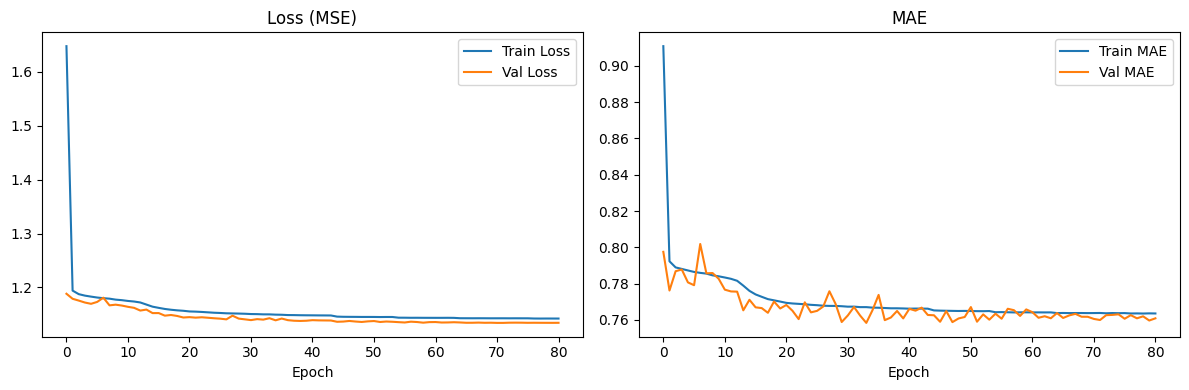


Test RMSE : 1.0709
Test MAE  : 0.7642


In [46]:
import tensorflow as tf
from tensorflow import keras


# Best parameters from search
best_params = {
    'hidden_units': [64, 32],
    'activation':   'relu',
    'lr':           0.001,
    'alpha':        0.0001
}

# Build model with best parameters
best_ann = keras.Sequential([
    keras.layers.Dense(
        best_params['hidden_units'][0],
        activation=best_params['activation'],
        kernel_regularizer=keras.regularizers.l2(best_params['alpha']),
        input_shape=(X_train_scaled.shape[1],)
    ),
    keras.layers.Dense(
        best_params['hidden_units'][1],
        activation=best_params['activation'],
        kernel_regularizer=keras.regularizers.l2(best_params['alpha'])
    ),
    keras.layers.Dense(1)   # output layer — no activation for regression
])

best_ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,               # more patience than search — full training deserves more
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                # halve lr when plateau hit
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Fit on full training data
history = best_ann.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Final evaluation on test set
test_loss, test_mae = best_ann.evaluate(X_test_scaled, y_test, verbose=0)
test_rmse = np.sqrt(test_loss)
print(f"\nTest RMSE : {test_rmse:.4f}")
print(f"Test MAE  : {test_mae:.4f}")

In [47]:
evaluate_model(best_ann, X_test_scaled, y_test)

   1/7500 ━━━━━━━━━━━━━━━━━━━━ 3:57 32ms/step

7500/7500 ━━━━━━━━━━━━━━━━━━━━ 1s 184us/step
[Sequential]
  Log scale  — RMSE: 1.0694 | MAE: 0.7642 | R2: 0.0509
  Orig scale — RMSE: 932.30 | MAE: 631.67 | R2: -0.1610


(np.float64(1.0693709349120162),
 0.7641752907186544,
 0.050898050850380905,
 np.float64(932.2993512286891),
 631.666498291715,
 -0.1609899084339499)

In [48]:
from sklearn.linear_model import Lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


param_dist = {
    'alpha':            np.logspace(-4, 2, 100),   # Wide range: 0.0001 to 100     
    'tol':              [1e-4, 1e-3, 1e-2],         # Convergence tolerance
    'selection':        ['cyclic', 'random']        # 'random' often converges faster on large data
}

lasso = Lasso(random_state=42)

random_search_lasso = RandomizedSearchCV(
    estimator=lasso,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    verbose=2,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search_lasso.fit(X_train_scaled, y_train)

print(f"Best parameters: {random_search_lasso.best_params_}")
print(f"Best CV RMSE:     {-random_search_lasso.best_score_:.4f}")
output: Best parameters: {'tol': 0.001, 'selection': 'cyclic', 'alpha': np.float64(0.0003511191734215131)}
Best CV RMSE:     1.0915


In [49]:
# Refit with best parameters
best_lasso = Lasso(
    tol= 0.001, 
    selection = 'cyclic',
    alpha = np.float64(0.0003511191734215131),
    random_state= 42
)

model_lasso = best_lasso.fit(X_train_scaled, y_train)

evaluate_model(model_lasso, X_test_scaled, y_test)

# See how many features were zeroed out
n_zeroed = np.sum(best_lasso.coef_ == 0)
n_total  = len(best_lasso.coef_)
print(f"Features zeroed out by Lasso: {n_zeroed}/{n_total}")

[Lasso]
  Log scale  — RMSE: 1.0934 | MAE: 0.7966 | R2: 0.0077
  Orig scale — RMSE: 939.12 | MAE: 650.22 | R2: -0.1780
Features zeroed out by Lasso: 5/21


/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


/var/folders/tx/1dyqxkm52yd54jrcwkb48jtc0000gp/T/ipykernel_29874/3540970052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=df_scores, palette='viridis')


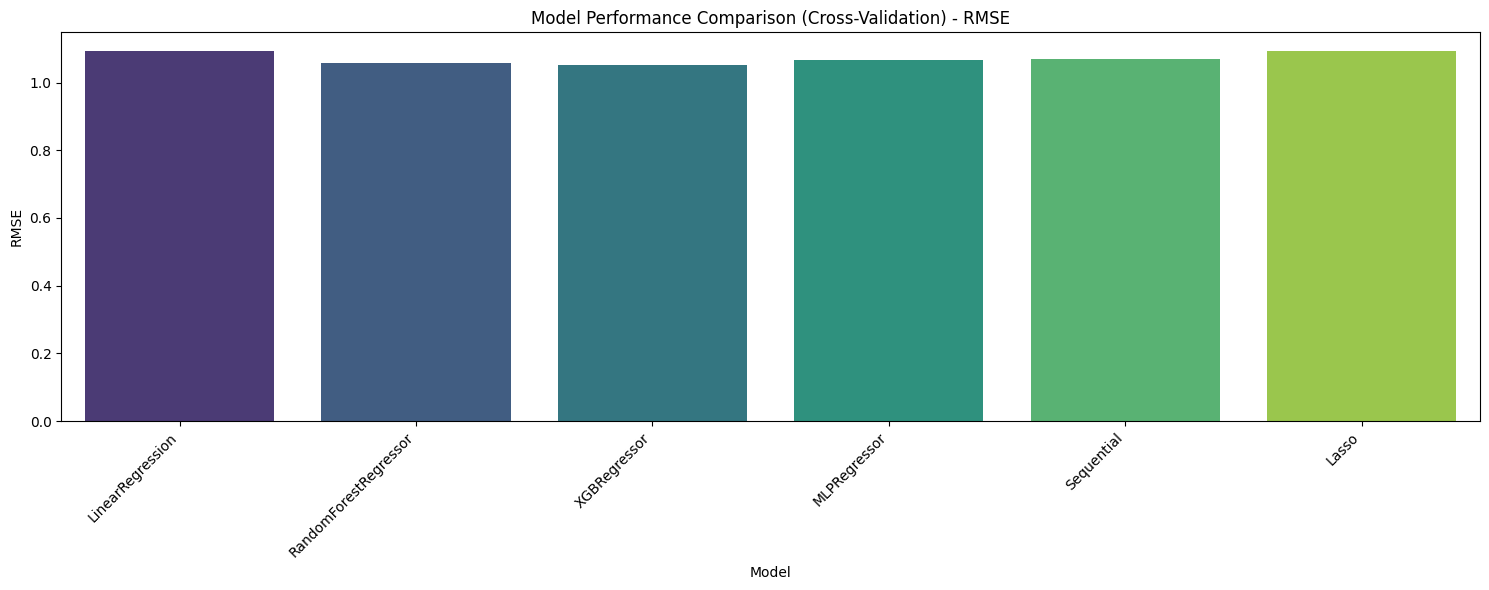

/var/folders/tx/1dyqxkm52yd54jrcwkb48jtc0000gp/T/ipykernel_29874/3540970052.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=df_scores, palette='viridis')


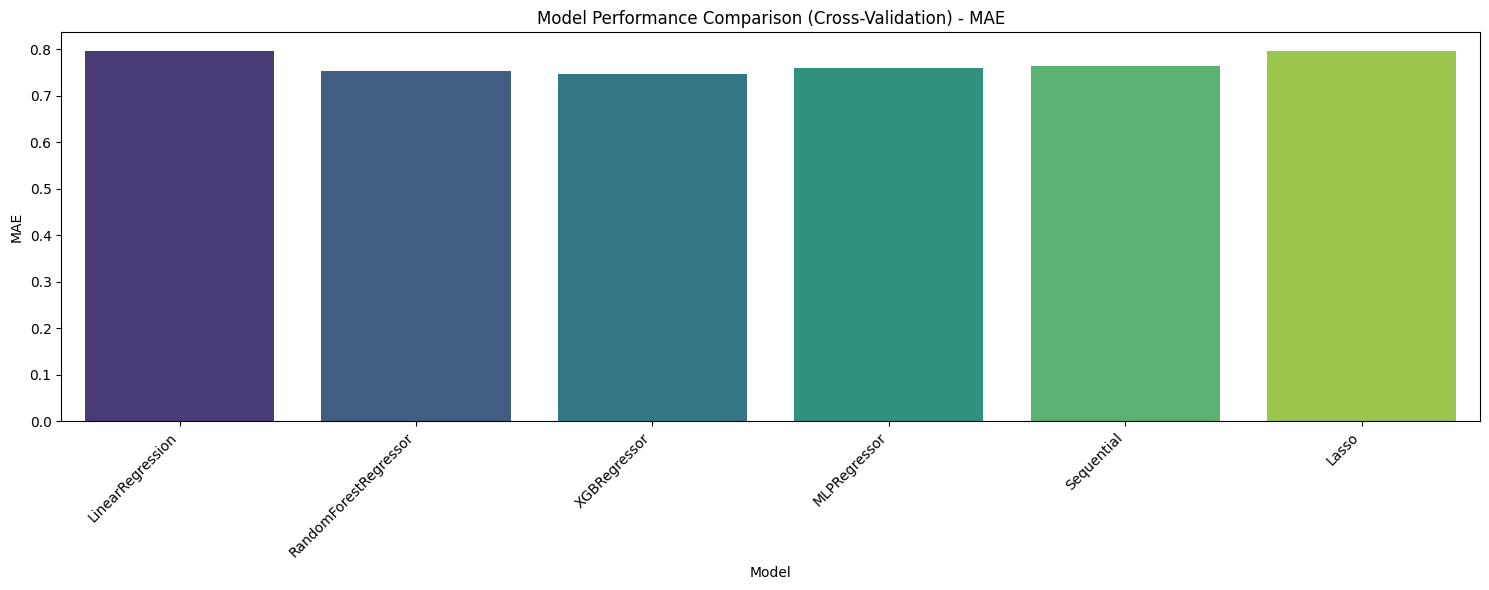

/var/folders/tx/1dyqxkm52yd54jrcwkb48jtc0000gp/T/ipykernel_29874/3540970052.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=df_scores, palette='viridis')


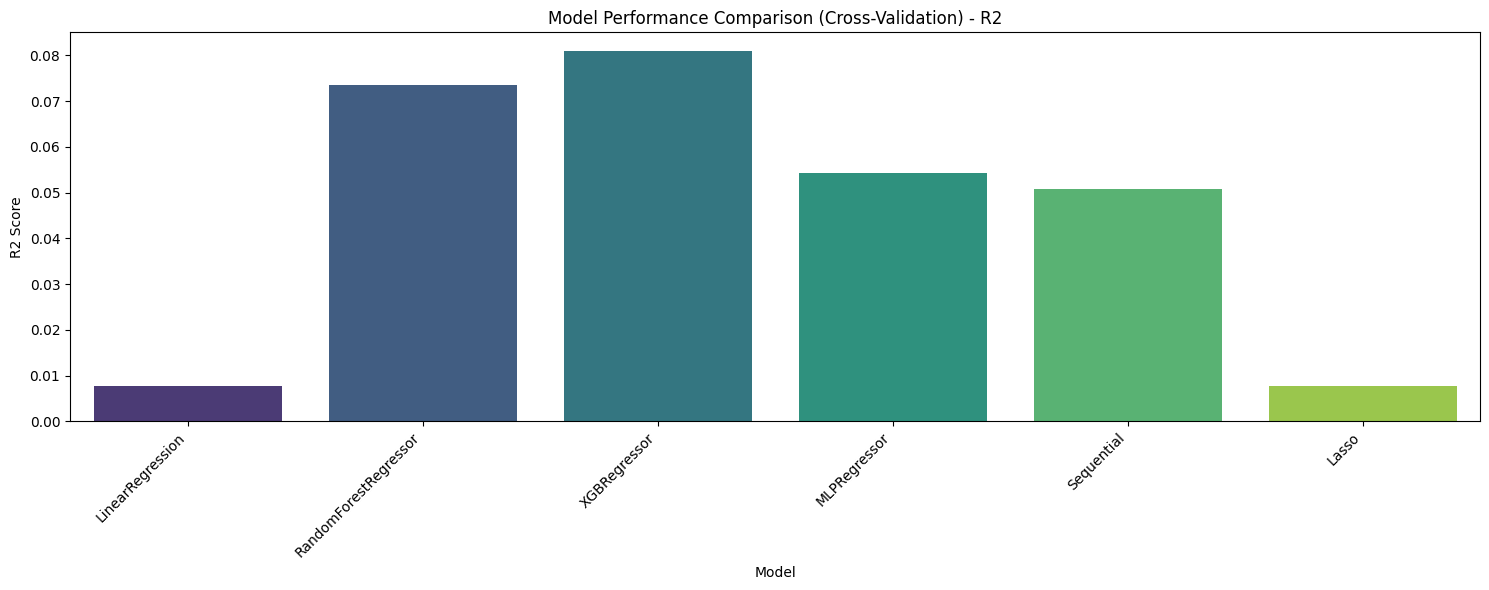

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
sns.barplot(x='Model', y='RMSE', data=df_scores, palette='viridis')
plt.title('Model Performance Comparison (Cross-Validation) - RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.barplot(x='Model', y='MAE', data=df_scores, palette='viridis')
plt.title('Model Performance Comparison (Cross-Validation) - MAE')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.barplot(x='Model', y='R2', data=df_scores, palette='viridis')
plt.title('Model Performance Comparison (Cross-Validation) - R2')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

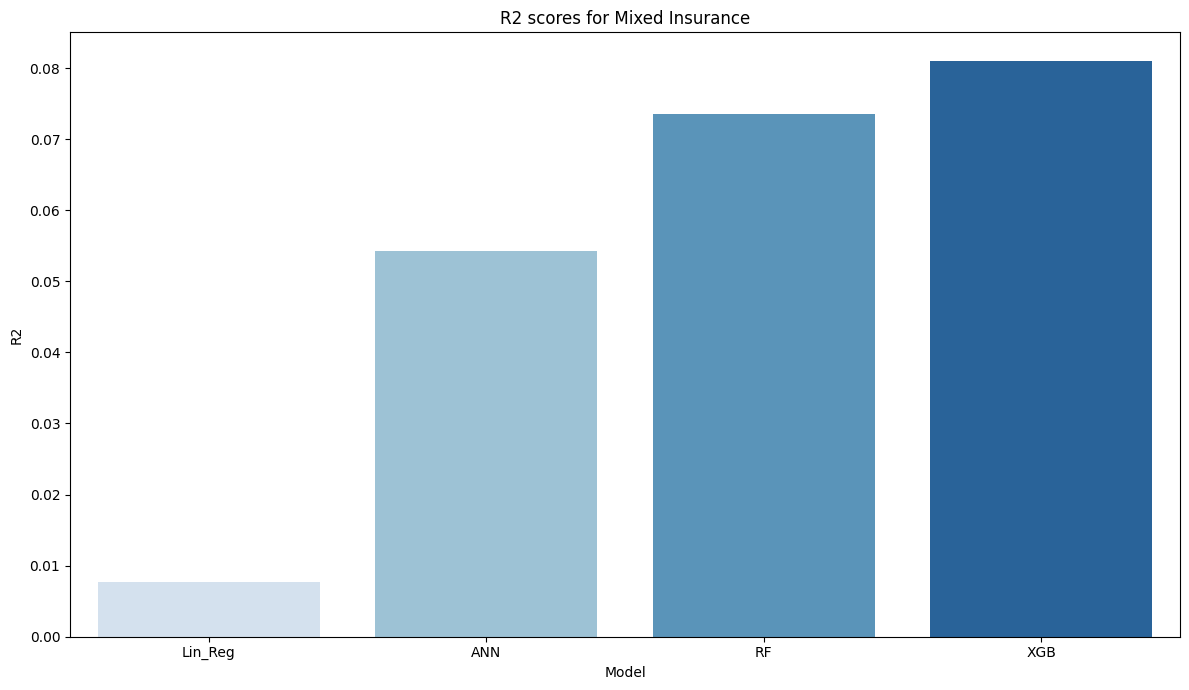

In [55]:
#for plot in poster
# Keep only selected models and one R2 per model (mean in case of duplicates)
specified_models_for_plot = ['LinearRegression', 'MLPRegressor', 'XGBRegressor', 'RandomForestRegressor']

plot_df = (
    df_scores[df_scores['Model'].isin(specified_models_for_plot)]
    .groupby('Model', as_index=False)['R2']
    .mean()
)

model_rename_map = {
    'LinearRegression': 'Lin_Reg',
    'MLPRegressor': 'ANN',
    'XGBRegressor': 'XGB',
    'RandomForestRegressor': 'RF'
}
plot_df['Model'] = plot_df['Model'].replace(model_rename_map)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x='Model',
    y='R2',
    hue='Model',         # needed for multi-color palette
    palette='Blues',
    dodge=False,
    legend=False
)
plt.title('R2 scores for Mixed Insurance')
plt.xlabel('Model')
plt.ylabel('R2')
plt.tight_layout()
plt.show()


In [56]:
feature_importances_xgb = model_xgb.feature_importances_
feature_names_xgb       = preprocessor.get_feature_names_out()

importance_df_xgb = pd.DataFrame({
    'Feature':    feature_names_xgb,
    'Importance': feature_importances_xgb
}).sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Features from Tuned XGBoost Model:")
display(importance_df_xgb.head(5))

Top 5 Most Important Features from Tuned XGBoost Model:


,Feature,Importance
4,num__Previous Claims,0.194627
11,ord__Customer Feedback,0.168388
1,num__Annual Income,0.126608
18,ohe__Marital Status_Unknown,0.123033
6,num__Credit Score,0.102085


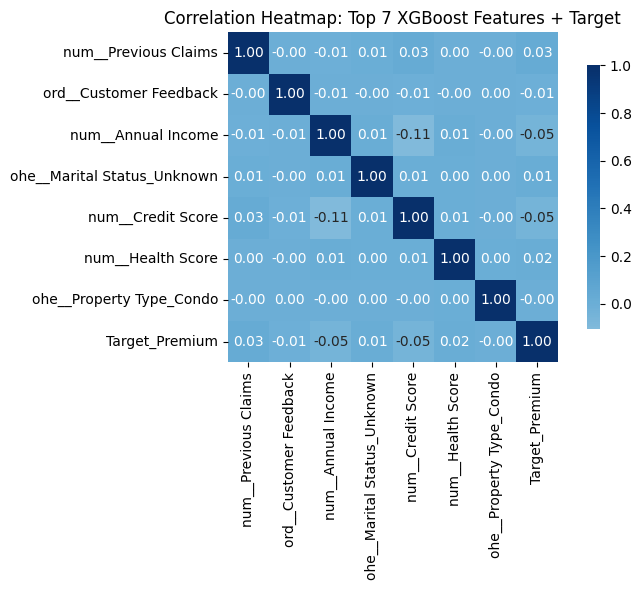

In [64]:
# Top 7 features from tuned XGBoost importance
top7_xgb_features = importance_df_xgb.head(7)['Feature'].tolist()

# Build smaller correlation matrix (top features + target)
small_corr = df_analysis[top7_xgb_features + ['Target_Premium']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    small_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap: Top 7 XGBoost Features + Target")
plt.tight_layout()
plt.show()

In [57]:
df2 = pd.read_csv('train_premium.csv')

In [58]:
df2.columns

Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

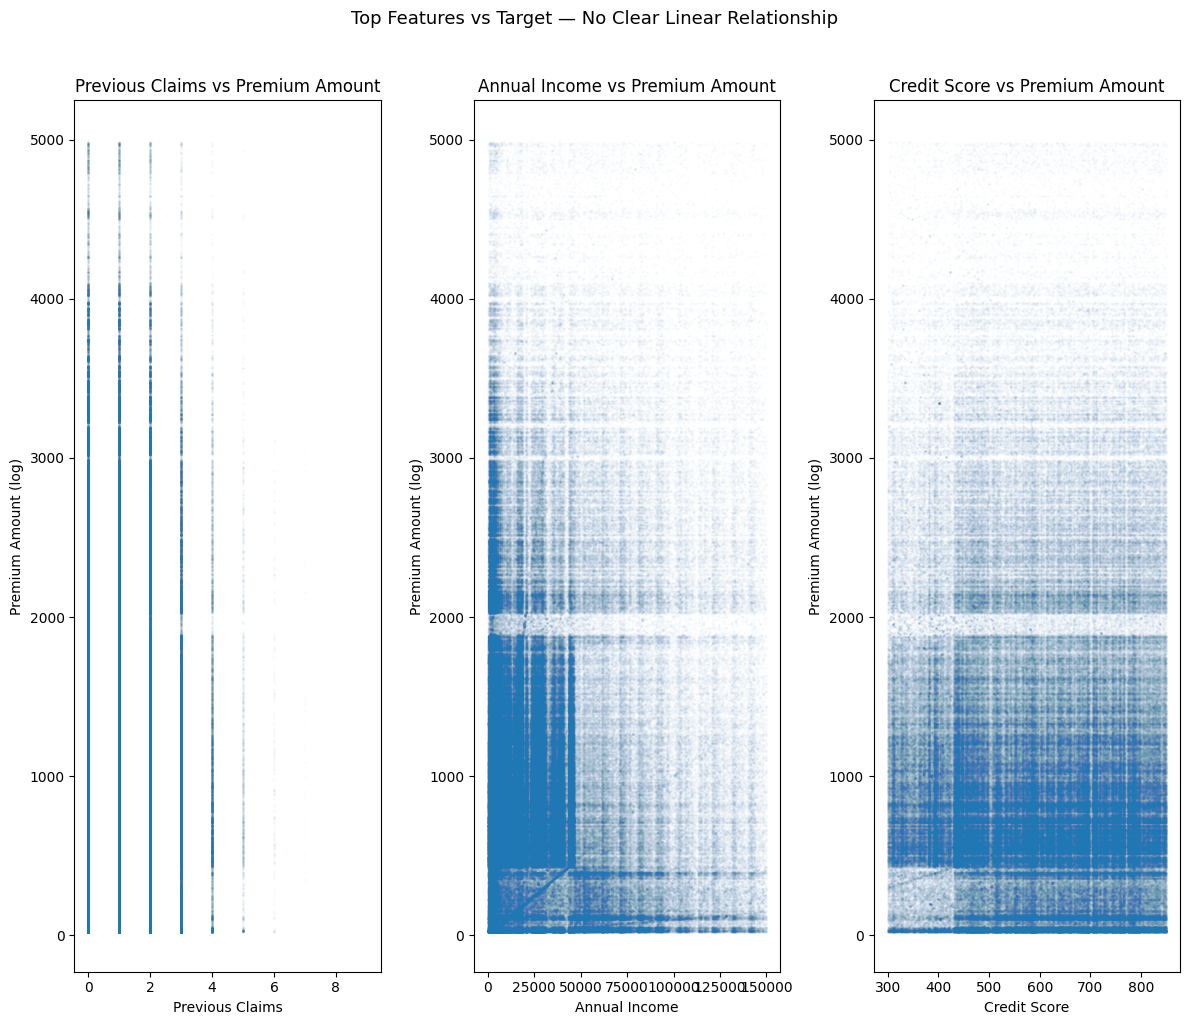

In [59]:
# Shows visually that even "important" features have no clear pattern with target
df2 = pd.read_csv('train_premium.csv')
top_features = ['Previous Claims', 'Annual Income', 'Credit Score']

fig, axes = plt.subplots(1, 3, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df2[feature], df2['Premium Amount'], 
                    alpha=0.01,           # low alpha needed for 1.2M points
                    s=1)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Premium Amount (log)')
    axes[i].set_title(f'{feature} vs Premium Amount')

plt.suptitle('Top Features vs Target — No Clear Linear Relationship', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [60]:
df2['Previous Claims'].unique()

array([ 2.,  1.,  0., nan,  3.,  4.,  5.,  6.,  7.,  8.,  9.])

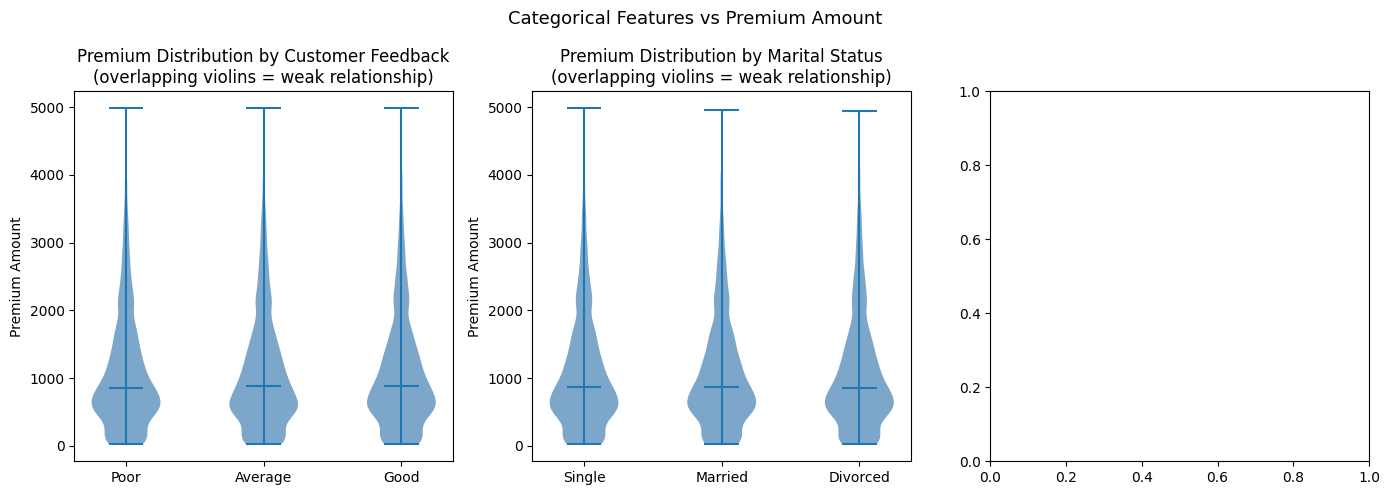

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cat_features_plot = ['Customer Feedback', 'Marital Status']
orders = {
    'Customer Feedback': ['Poor', 'Average', 'Good'],
    'Marital Status':    ['Single', 'Married', 'Divorced']
}

for ax, feature in zip(axes, cat_features_plot):
    order = orders[feature]
    
    data_by_cat = [df2[df2[feature] == cat]['Premium Amount'].dropna().sample(
                   min(10000, len(df2[df2[feature] == cat])),  # subsample for speed
                   random_state=42) 
                   for cat in order]
    
    parts = ax.violinplot(data_by_cat, positions=range(len(order)), 
                          showmedians=True, showmeans=False)
    
    # Color the violins
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.7)
    
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_ylabel('Premium Amount')
    ax.set_title(f'Premium Distribution by {feature}\n(overlapping violins = weak relationship)')

plt.suptitle('Categorical Features vs Premium Amount', fontsize=13)
plt.tight_layout()
plt.show()

In [62]:
feature_importances_rf = model_rf.feature_importances_
feature_names_rf = preprocessor.get_feature_names_out()
# Verify lengths match before building DataFrame
print(f"Feature names length : {len(feature_names_rf)}")
print(f"Importances length   : {len(feature_importances_rf)}")

importance_df_rf = pd.DataFrame({
    'Feature':    feature_names_rf,
    'Importance': feature_importances_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Features from Tuned RandomForestRegressor Model:")
display(importance_df_rf.head(5))

Feature names length : 21
Importances length   : 21
Top 5 Most Important Features from Tuned RandomForestRegressor Model:


,Feature,Importance
1,num__Annual Income,0.235464
6,num__Credit Score,0.166479
3,num__Health Score,0.135135
0,num__Age,0.077400
5,num__Vehicle Age,0.062922


In [ ]:
print(f"y variance      : {y.var():.4f}")
print(f"y std deviation : {y.std():.4f}")
print(f"y min           : {y.min():.4f}")
print(f"y max           : {y.max():.4f}")
print(f"y range         : {y.max() - y.min():.4f}")

y variance      : 1.2008
y std deviation : 1.0958
y min           : 3.0445
y max           : 8.5172
y range         : 5.4727


In [ ]:
evaluate_model(model_lr,  X_test_scaled, y_test)
evaluate_model(model_rf,  X_test_scaled, y_test)
evaluate_model(model_xgb, X_test_scaled, y_test)

[LinearRegression]
  Log scale  — RMSE: 1.0934 | MAE: 0.7967 | R2: 0.0077
  Orig scale — RMSE: 939.09 | MAE: 650.22 | R2: -0.1780


/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/aayusha/Downloads/URS/premium prediction with regression/venv_64/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


[RandomForestRegressor]
  Log scale  — RMSE: 1.0565 | MAE: 0.7526 | R2: 0.0735
  Orig scale — RMSE: 928.81 | MAE: 625.69 | R2: -0.1523
[XGBRegressor]
  Log scale  — RMSE: 1.0523 | MAE: 0.7470 | R2: 0.0810
  Orig scale — RMSE: 925.75 | MAE: 622.25 | R2: -0.1447


(np.float64(1.0522688583252993),
 0.7470300191448352,
 0.08101261713091001,
 np.float64(925.7499166511969),
 622.253351047643,
 -0.14473521756131702)

In [ ]:
cat_features = ['Gender', 'Marital Status', 'Property Type',
                'Education Level', 'Occupation', 'Location',
                'Customer Feedback', 'Policy Type',
                'Smoking Status', 'Exercise Frequency']

num_features = ['Age', 'Annual Income', 'Number of Dependents', 'Health Score',
                'Previous Claims', 'Vehicle Age', 'Credit Score', 
                'Insurance Duration', 'Income_Missing']

# Now fill nulls safely
for col in cat_features:
    X_train_cat[col] = X_train_cat[col].fillna('Unknown').astype(str)
    X_test_cat[col]  = X_test_cat[col].fillna('Unknown').astype(str)

for col in num_features:
    median_val = X_train_cat[col].median()
    X_train_cat[col] = X_train_cat[col].fillna(median_val)
    X_test_cat[col]  = X_test_cat[col].fillna(median_val)

print("Nulls remaining in train:", X_train_cat.isnull().sum().sum())
print("Nulls remaining in test :", X_test_cat.isnull().sum().sum())
print("Columns in data:", X_train_cat.columns.tolist())

Nulls remaining in train: 0
Nulls remaining in test : 0
Columns in data: ['Age', 'Gender', 'Annual Income', 'Marital Status', 'Number of Dependents', 'Education Level', 'Occupation', 'Health Score', 'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type', 'Income_Missing']


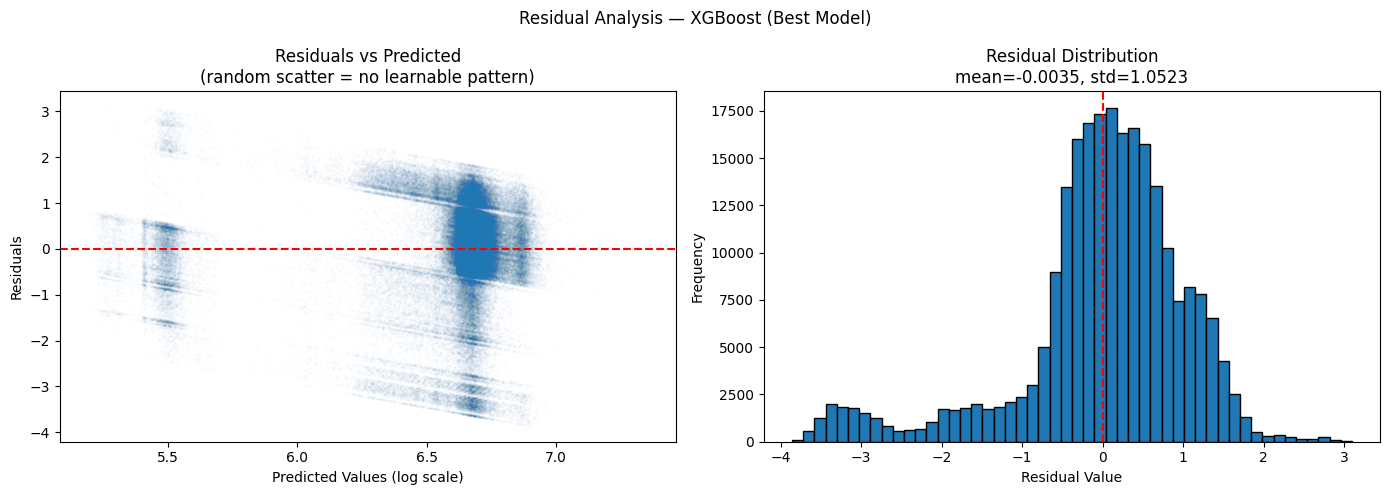

In [ ]:
# Shows residuals are essentially random — model learned nothing systematic
best_model    = model_xgb   # replace with whichever had best R2
predictions   = best_model.predict(X_test_scaled)
residuals     = y_test.values - predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted
axes[0].scatter(predictions, residuals, alpha=0.01, s=1)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted\n(random scatter = no learnable pattern)')

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution\nmean={residuals.mean():.4f}, std={residuals.std():.4f}')

plt.suptitle('Residual Analysis — XGBoost (Best Model)', fontsize=12)
plt.tight_layout()
plt.show()